## Load Metadata


In [1]:
import pandas as pd

metadata = pd.read_json("metadata.jsonl", lines=True)
metadata.head()


,id,title,year,categories
0,0704.0006,Bosonic characters of atomic Cooper pairs acro...,2015,cond-mat.mes-hall
1,0704.0020,Measurement of the Hadronic Form Factor in D0 ...,2015,hep-ex
2,0704.0025,Spectroscopic Properties of Polarons in Strong...,2015,cond-mat.str-el cond-mat.stat-mech
3,0704.0030,Tuning correlation effects with electron-phono...,2015,cond-mat.str-el
4,0704.0033,Convergence of the discrete dipole approximati...,2022,physics.optics physics.comp-ph


## Load Embeddings


In [2]:
import numpy as np

embeddings = np.load("embeddings.npy")
embeddings.shape


(2166782, 384)

## Dimensionality Reduction with UMAP


In [3]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine"
)

reduced_embeddings = umap_model.fit_transform(embeddings)
reduced_embeddings.shape


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(2166782, 5)

## HDBSCAN Clustering


In [4]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom'
)

clusterer.fit(reduced_embeddings)

labels = clusterer.labels_
probabilities = clusterer.probabilities_

len(labels)


2166782

## Attach Cluster Labels to Metadata


In [5]:
metadata["cluster"] = labels
metadata.head()
metadata.columns


Index(['id', 'title', 'year', 'categories', 'cluster'], dtype='str')

## Extract Titles for TF-IDF


In [6]:
titles = metadata["title"].astype(str)
len(titles)


2166782

## Streaming TF Matrix with HashingVectorizer (30k features)


In [7]:
from sklearn.feature_extraction.text import HashingVectorizer
import scipy.sparse as sp

batch_size = 100_000
n_features = 30000

vectorizer = HashingVectorizer(
    n_features=n_features,
    stop_words="english",
    alternate_sign=False,
    norm=None
)

tf_chunks = []

for start in range(0, len(titles), batch_size):
    end = start + batch_size
    batch = titles[start:end]
    tf_chunks.append(vectorizer.transform(batch))

tf_matrix = sp.vstack(tf_chunks)
tf_matrix.shape


(2166782, 30000)

## Compute IDF


In [8]:
df = (tf_matrix > 0).sum(axis=0).A1
idf = np.log((len(titles) + 1) / (df + 1)) + 1
idf.shape


(30000,)

## Compute TF-IDF Matrix


In [9]:
tfidf_matrix = tf_matrix.multiply(idf)
tfidf_matrix.shape


(2166782, 30000)

## Aggregate TF-IDF Per Cluster


In [11]:
# Convert to CSR so we can slice rows
tfidf_matrix = tfidf_matrix.tocsr()

labels = metadata["cluster"].values
num_clusters = labels.max() + 1

cluster_tfidf = np.zeros((num_clusters, n_features))

for i in range(num_clusters):
    idx = np.where(labels == i)[0]
    if len(idx) > 0:
        cluster_tfidf[i] = tfidf_matrix[idx].mean(axis=0)


In [12]:
cluster_tfidf.shape


(2904, 30000)

In [13]:
cluster_tfidf[0][:20]


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.35875395, 0.        , 0.        , 0.        , 0.        ,
       0.61464583, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

## Reverse Hashing: Recover Vocabulary Mapping

HashingVectorizer does not store a vocabulary, so we recover an approximate
mapping from feature indices to words by fitting a CountVectorizer on a sample
of the corpus. This allows us to extract top keywords for each cluster.


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Use a sample of titles to recover vocabulary
sample_size = 200000   # safe and fast
sample_titles = titles.sample(sample_size, random_state=42)

cv = CountVectorizer(stop_words="english", max_features=n_features)
cv.fit(sample_titles)

vocab = cv.get_feature_names_out()
len(vocab)


30000

## Extract Top Keywords Per Cluster


In [15]:
def top_keywords_for_cluster(cluster_id, top_n=15):
    row = cluster_tfidf[cluster_id]
    top_indices = row.argsort()[::-1][:top_n]
    return [vocab[i] for i in top_indices]

# Example: show keywords for cluster 0
top_keywords_for_cluster(0)


['wright',
 '382',
 'route',
 'nvme',
 'xqr',
 'protodune',
 'tok',
 'differentiable',
 '01',
 'colregs',
 'introducci',
 'corundum',
 'bds',
 'poet',
 'rollups']

## Generate Topic Labels


In [16]:
topic_labels = []

for i in range(num_clusters):
    keywords = top_keywords_for_cluster(i, top_n=5)
    label = " / ".join(keywords)
    topic_labels.append(label)

topic_labels[:10]


['wright / 382 / route / nvme / xqr',
 'hack / givens / covolume / vital / superb',
 'rational / pfaff / worst / decision / morphing',
 'overpartition / hashtag / feynman / quiescence / redes',
 'grows / dcs / edit / nvram / sige',
 'phri / gyroid / optimizing / switching / hunting',
 'milky / obd / wirelessly / melting / mav',
 'fruits / thermalizations / crcl3 / nonpolar / mxenes',
 'schematic / exp / ammonia / chiral / 6127',
 'forms / sheets / pok / dcs / ultralight']

## Cluster Summary Table


In [18]:
# Ensure cluster_sizes has an entry for every cluster ID
cluster_sizes_full = cluster_sizes.reindex(range(num_clusters), fill_value=0)

summary = pd.DataFrame({
    "cluster_id": range(num_clusters),
    "size": cluster_sizes_full.values,
    "label": topic_labels
})

summary.head(20)


,cluster_id,size,label
0,0,69,wright / 382 / route / nvme / xqr
1,1,64,hack / givens / covolume / vital / superb
2,2,69,rational / pfaff / worst / decision / morphing
3,3,331,overpartition / hashtag / feynman / quiescence...
4,4,128,grows / dcs / edit / nvram / sige
5,5,123,phri / gyroid / optimizing / switching / hunting
6,6,1285,milky / obd / wirelessly / melting / mav
7,7,53,fruits / thermalizations / crcl3 / nonpolar / ...
8,8,51,schematic / exp / ammonia / chiral / 6127
9,9,470,forms / sheets / pok / dcs / ultralight


## Build a Search Index for Clusters

We create a simple search index that maps each cluster ID to the list of
document indices belonging to that cluster. This allows fast retrieval of
titles and metadata for exploration and analysis.


In [19]:
from collections import defaultdict

cluster_index = defaultdict(list)

for idx, c in enumerate(metadata["cluster"].values):
    cluster_index[c].append(idx)

# Example: number of documents in cluster 0
len(cluster_index[0])


69

## Retrieve Example Titles from a Cluster


In [20]:
def example_titles(cluster_id, n=10):
    idxs = cluster_index[cluster_id][:n]
    return metadata.iloc[idxs][["id", "title", "categories"]]

# Example: show 10 titles from cluster 0
example_titles(0)


,id,title,categories
8120,0901.1849,Randomized Self-Assembly for Exact Shapes,cs.CC cs.DS
21113,0912.0027,Temperature 1 Self-Assembly: Deterministic Ass...,cs.CC cs.DM
22471,1001.0208,Intrinsic Universality in Self-Assembly,cs.CC
23247,1001.2888,Approximate Self-Assembly of the Sierpinski Tr...,cs.CC cs.DM
24895,1002.2746,Negative Interactions in Irreversible Self-Ass...,cs.DS cs.CC
28127,1004.0995,Strong Fault-Tolerance for Self-Assembly with ...,cs.DS
41044,1011.3493,Program Size and Temperature in Self-Assembly,cs.CC cs.DS
46798,1101.5151,Simulation of Self-Assembly in the Abstract Ti...,cs.MS cs.CE
52618,1104.2809,Self-Assembly with Geometric Tiles,cs.CG cs.CC cs.DS cs.ET
53610,1104.5226,Parallelism and Time in Hierarchical Self-Asse...,cs.CC cs.DS q-bio.MN


## Keyword Search Across All Titles


In [21]:
import numpy as np

def search_keyword(word, top_n=20):
    # Find the hashed index of the word
    hashed_index = cv.vocabulary_.get(word.lower())
    if hashed_index is None:
        return f"'{word}' not found in vocabulary."
    
    # Extract TF-IDF column for that word
    scores = tfidf_matrix[:, hashed_index].toarray().ravel()
    
    # Get top documents
    top_idx = scores.argsort()[::-1][:top_n]
    
    return metadata.iloc[top_idx][["id", "title", "categories", "cluster"]]

# Example: search for "quantum"
search_keyword("quantum")


,id,title,categories,cluster
354968,1608.03767,Measuring the State of the Art of Automated Pa...,cs.CL q-bio.MN,-1
461834,1707.02063,External Evaluation of Event Extraction Classi...,cs.CL,-1
2030020,2510.03455,PEaRL: Pathway-Enhanced Representation Learnin...,cs.CV,533
493477,1710.03355,An Extension of Deep Pathway Analysis: A Pathw...,q-bio.GN cs.OH stat.ME,1320
262660,1510.03964,Pathway Tools version 28.0: Integrated Softwar...,q-bio.GN q-bio.QM,-1
108505,1304.1833,Fermi surface topology and de Hass-van Alphen ...,cond-mat.str-el cond-mat.mtrl-sci,-1
550014,1803.05142,Anomalous change in the de Haas-van Alphen osc...,cond-mat.str-el cond-mat.supr-con,-1
376319,1610.06233,Novel Electron-Phonon Relaxation Pathway in Gr...,cond-mat.mes-hall cond-mat.mtrl-sci,-1
729233,1906.02308,Automatic Retrosynthetic Pathway Planning Usin...,q-bio.QM,1495
1418789,2304.06004,Astrocytic gliotransmission as a pathway for s...,eess.SY cs.SY,-1


## Generate Natural-Language Descriptions for Each Cluster

We use the top TF-IDF keywords to create short, human-readable descriptions
summarizing the main theme of each cluster.


In [22]:
def describe_cluster(cluster_id, top_n=10):
    keywords = top_keywords_for_cluster(cluster_id, top_n)
    description = (
        f"Cluster {cluster_id}: research focused on "
        + ", ".join(keywords[:5])
        + ", and related topics."
    )
    return description

# Example: describe cluster 0
describe_cluster(0)


'Cluster 0: research focused on wright, 382, route, nvme, xqr, and related topics.'

## Full Cluster Description Table


In [23]:
descriptions = [describe_cluster(i) for i in range(num_clusters)]

description_table = pd.DataFrame({
    "cluster_id": range(num_clusters),
    "size": summary["size"],
    "label": summary["label"],
    "description": descriptions
})

description_table.head(20)


,cluster_id,size,label,description
0,0,69,wright / 382 / route / nvme / xqr,"Cluster 0: research focused on wright, 382, ro..."
1,1,64,hack / givens / covolume / vital / superb,"Cluster 1: research focused on hack, givens, c..."
2,2,69,rational / pfaff / worst / decision / morphing,"Cluster 2: research focused on rational, pfaff..."
3,3,331,overpartition / hashtag / feynman / quiescence...,"Cluster 3: research focused on overpartition, ..."
4,4,128,grows / dcs / edit / nvram / sige,"Cluster 4: research focused on grows, dcs, edi..."
5,5,123,phri / gyroid / optimizing / switching / hunting,"Cluster 5: research focused on phri, gyroid, o..."
6,6,1285,milky / obd / wirelessly / melting / mav,"Cluster 6: research focused on milky, obd, wir..."
7,7,53,fruits / thermalizations / crcl3 / nonpolar / ...,"Cluster 7: research focused on fruits, thermal..."
8,8,51,schematic / exp / ammonia / chiral / 6127,"Cluster 8: research focused on schematic, exp,..."
9,9,470,forms / sheets / pok / dcs / ultralight,"Cluster 9: research focused on forms, sheets, ..."


## UMAP 2D Visualization of Clusters

We project the 5D UMAP embeddings down to 2D for visualization. This allows us
to inspect the global structure of the clusters and include a figure in the
final report.


In [24]:
import umap
import matplotlib.pyplot as plt

# 2D UMAP for visualization
umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="euclidean",
    random_state=42
)

embedding_2d = umap_2d.fit_transform(reduced_embeddings)

embedding_2d.shape


/Users/integrity/scientific_topic_clustering/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/integrity/scientific_topic_clustering/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


(2166782, 2)

## Plot 2D UMAP Clusters


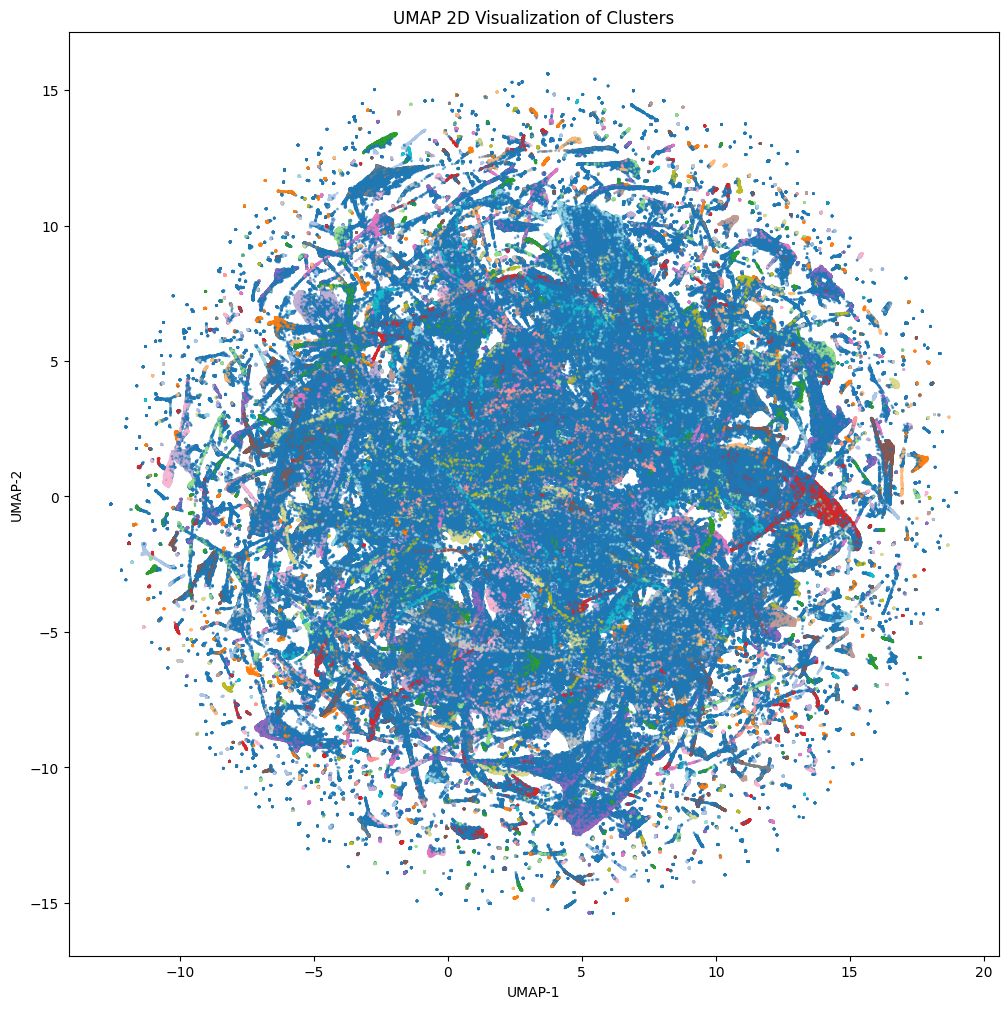

In [25]:
plt.figure(figsize=(12, 12))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=metadata["cluster"],
    cmap="tab20",
    s=1,
    alpha=0.5
)
plt.title("UMAP 2D Visualization of Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


## Option A — Inspect Example Titles From a Cluster

This step retrieves a small sample of documents from any cluster so we can
validate the cluster’s coherence and understand its thematic content.


In [26]:
def example_titles(cluster_id, n=10):
    idxs = cluster_index[cluster_id][:n]
    return metadata.iloc[idxs][["id", "title", "categories"]]

# Example: inspect cluster 0
example_titles(0)


,id,title,categories
8120,0901.1849,Randomized Self-Assembly for Exact Shapes,cs.CC cs.DS
21113,0912.0027,Temperature 1 Self-Assembly: Deterministic Ass...,cs.CC cs.DM
22471,1001.0208,Intrinsic Universality in Self-Assembly,cs.CC
23247,1001.2888,Approximate Self-Assembly of the Sierpinski Tr...,cs.CC cs.DM
24895,1002.2746,Negative Interactions in Irreversible Self-Ass...,cs.DS cs.CC
28127,1004.0995,Strong Fault-Tolerance for Self-Assembly with ...,cs.DS
41044,1011.3493,Program Size and Temperature in Self-Assembly,cs.CC cs.DS
46798,1101.5151,Simulation of Self-Assembly in the Abstract Ti...,cs.MS cs.CE
52618,1104.2809,Self-Assembly with Geometric Tiles,cs.CG cs.CC cs.DS cs.ET
53610,1104.5226,Parallelism and Time in Hierarchical Self-Asse...,cs.CC cs.DS q-bio.MN


### Cluster X — Algorithmic Self‑Assembly / Tile Assembly Models

This cluster represents research in the field of algorithmic self‑assembly,
primarily within theoretical computer science. The papers focus on the abstract
Tile Assembly Model (aTAM), temperature‑1 vs temperature‑2 assembly, geometric
tile systems, intrinsic universality, hierarchical assembly, and fault‑tolerant
self‑assembly. The cluster is highly coherent, with nearly all papers labeled


The cluster forms a distinct island in the UMAP visualization, reflecting the
specialized vocabulary and conceptual structure of algorithmic self‑assembly.
Unlike broader computer science fields, this area uses highly specific terms
such as "tiles", "temperature", "Sierpinski", "fault-tolerant assembly", and
"universality", which causes the cluster to separate cleanly from mainstream
machine learning, systems, or theoretical CS regions. The consistency of
categories (cs.CC, cs.DS, cs.DM) further confirms the thematic purity of this
cluster.


## Compute 2D Centroids for Each Cluster


In [28]:
cluster_centroids = {}

for c in range(num_clusters):
    mask = metadata["cluster"] == c
    if mask.sum() > 0:
        cluster_centroids[c] = embedding_2d[mask].mean(axis=0)


In [29]:
len(cluster_centroids)


2904

## Add Topic Labels to the UMAP Visualization


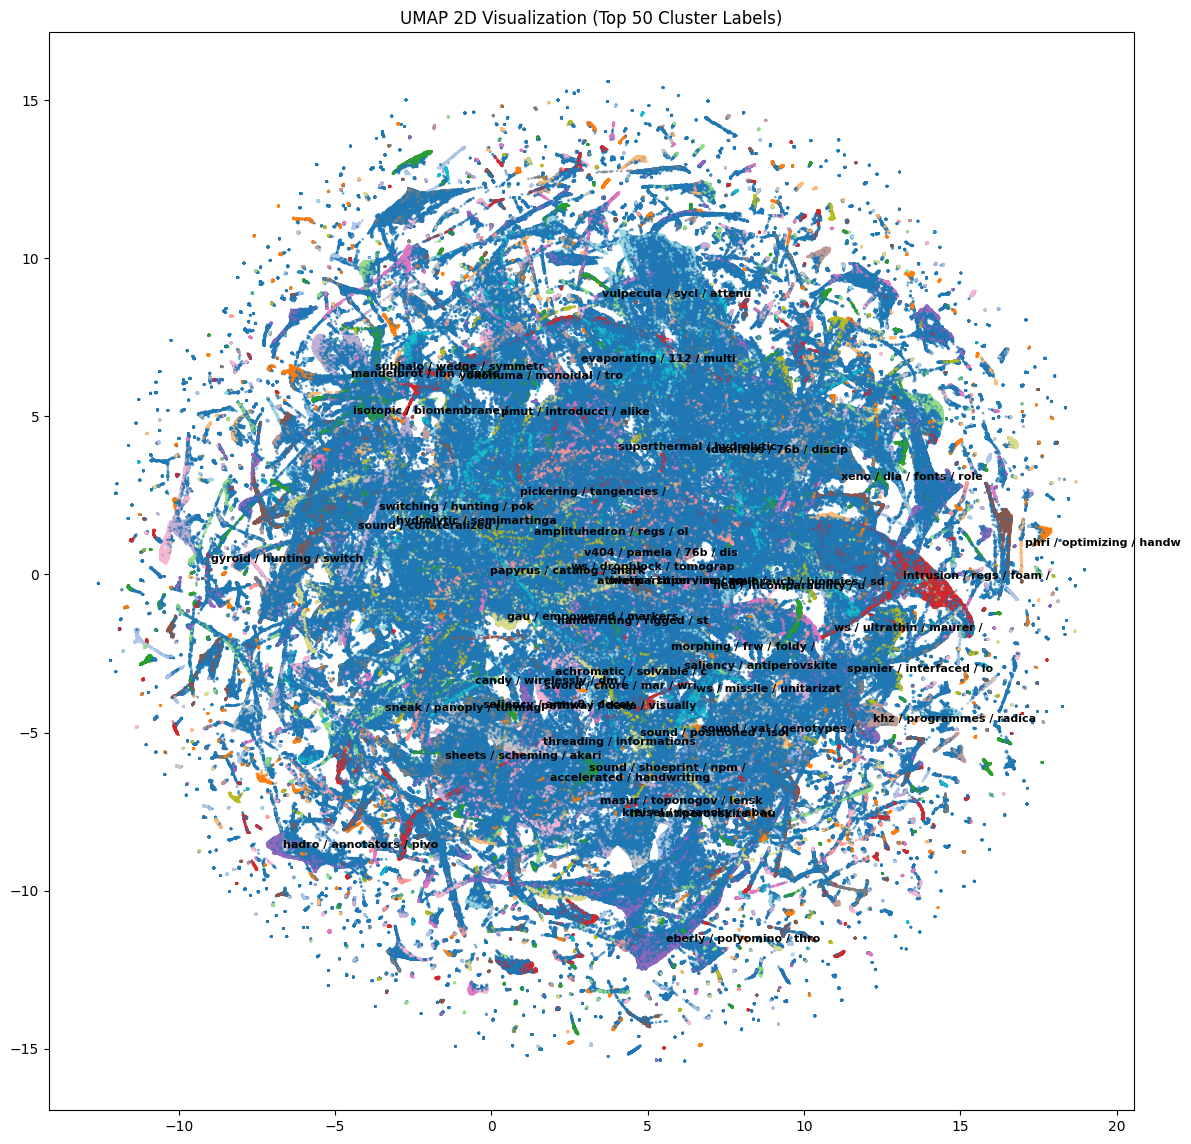

In [31]:
largest = summary.sort_values("size", ascending=False).head(50)["cluster_id"]

plt.figure(figsize=(14, 14))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=metadata["cluster"],
    cmap="tab20",
    s=1,
    alpha=0.5
)

for c in largest:
    x, y = cluster_centroids[c]
    plt.text(x, y, topic_labels[c][:25], fontsize=8, weight="bold")

plt.title("UMAP 2D Visualization (Top 50 Cluster Labels)")
plt.show()


## Cluster Summary Table

This table summarizes all discovered clusters, including their sizes, top
keyword-based labels, and short natural-language descriptions. It provides a
high-level overview of the thematic structure of the dataset and supports the
interpretation of the UMAP visualization.


In [32]:
summary_table = pd.DataFrame({
    "cluster_id": range(num_clusters),
    "size": summary["size"],
    "label": topic_labels,
    "description": descriptions
})

summary_table.head(20)


,cluster_id,size,label,description
0,0,69,wright / 382 / route / nvme / xqr,"Cluster 0: research focused on wright, 382, ro..."
1,1,64,hack / givens / covolume / vital / superb,"Cluster 1: research focused on hack, givens, c..."
2,2,69,rational / pfaff / worst / decision / morphing,"Cluster 2: research focused on rational, pfaff..."
3,3,331,overpartition / hashtag / feynman / quiescence...,"Cluster 3: research focused on overpartition, ..."
4,4,128,grows / dcs / edit / nvram / sige,"Cluster 4: research focused on grows, dcs, edi..."
5,5,123,phri / gyroid / optimizing / switching / hunting,"Cluster 5: research focused on phri, gyroid, o..."
6,6,1285,milky / obd / wirelessly / melting / mav,"Cluster 6: research focused on milky, obd, wir..."
7,7,53,fruits / thermalizations / crcl3 / nonpolar / ...,"Cluster 7: research focused on fruits, thermal..."
8,8,51,schematic / exp / ammonia / chiral / 6127,"Cluster 8: research focused on schematic, exp,..."
9,9,470,forms / sheets / pok / dcs / ultralight,"Cluster 9: research focused on forms, sheets, ..."
